In [22]:
import pandas as pd
from bsse_calculator.plotting_helpers import (
    make_bsse_contour_plots,
    fit_gaussian,
    make_contour_plots_of_fitted_gaussian,
    predicted_v_actual_plot,
    make_error_contour_plots,
)

In [23]:
bsse_data_nwchem_kcal = pd.read_csv("water_bsse_by_coords.csv")
extra_data = pd.read_csv("BSSE_by_H2O_H2O_distance_nwchem_more_distances.csv")

In [24]:
bsse_data_nwchem_kcal = pd.concat(
    [bsse_data_nwchem_kcal, extra_data], ignore_index=True
)
bsse_data_nwchem_kcal["BSSE_A"] = bsse_data_nwchem_kcal["BSSE_A"] * 627.5096
bsse_data_nwchem_kcal["BSSE_B"] = bsse_data_nwchem_kcal["BSSE_B"] * 627.5096
bsse_data_nwchem_kcal["Delta_E_AB_AB"] = (
    bsse_data_nwchem_kcal["Delta_E_AB_AB"] * 627.5096
)

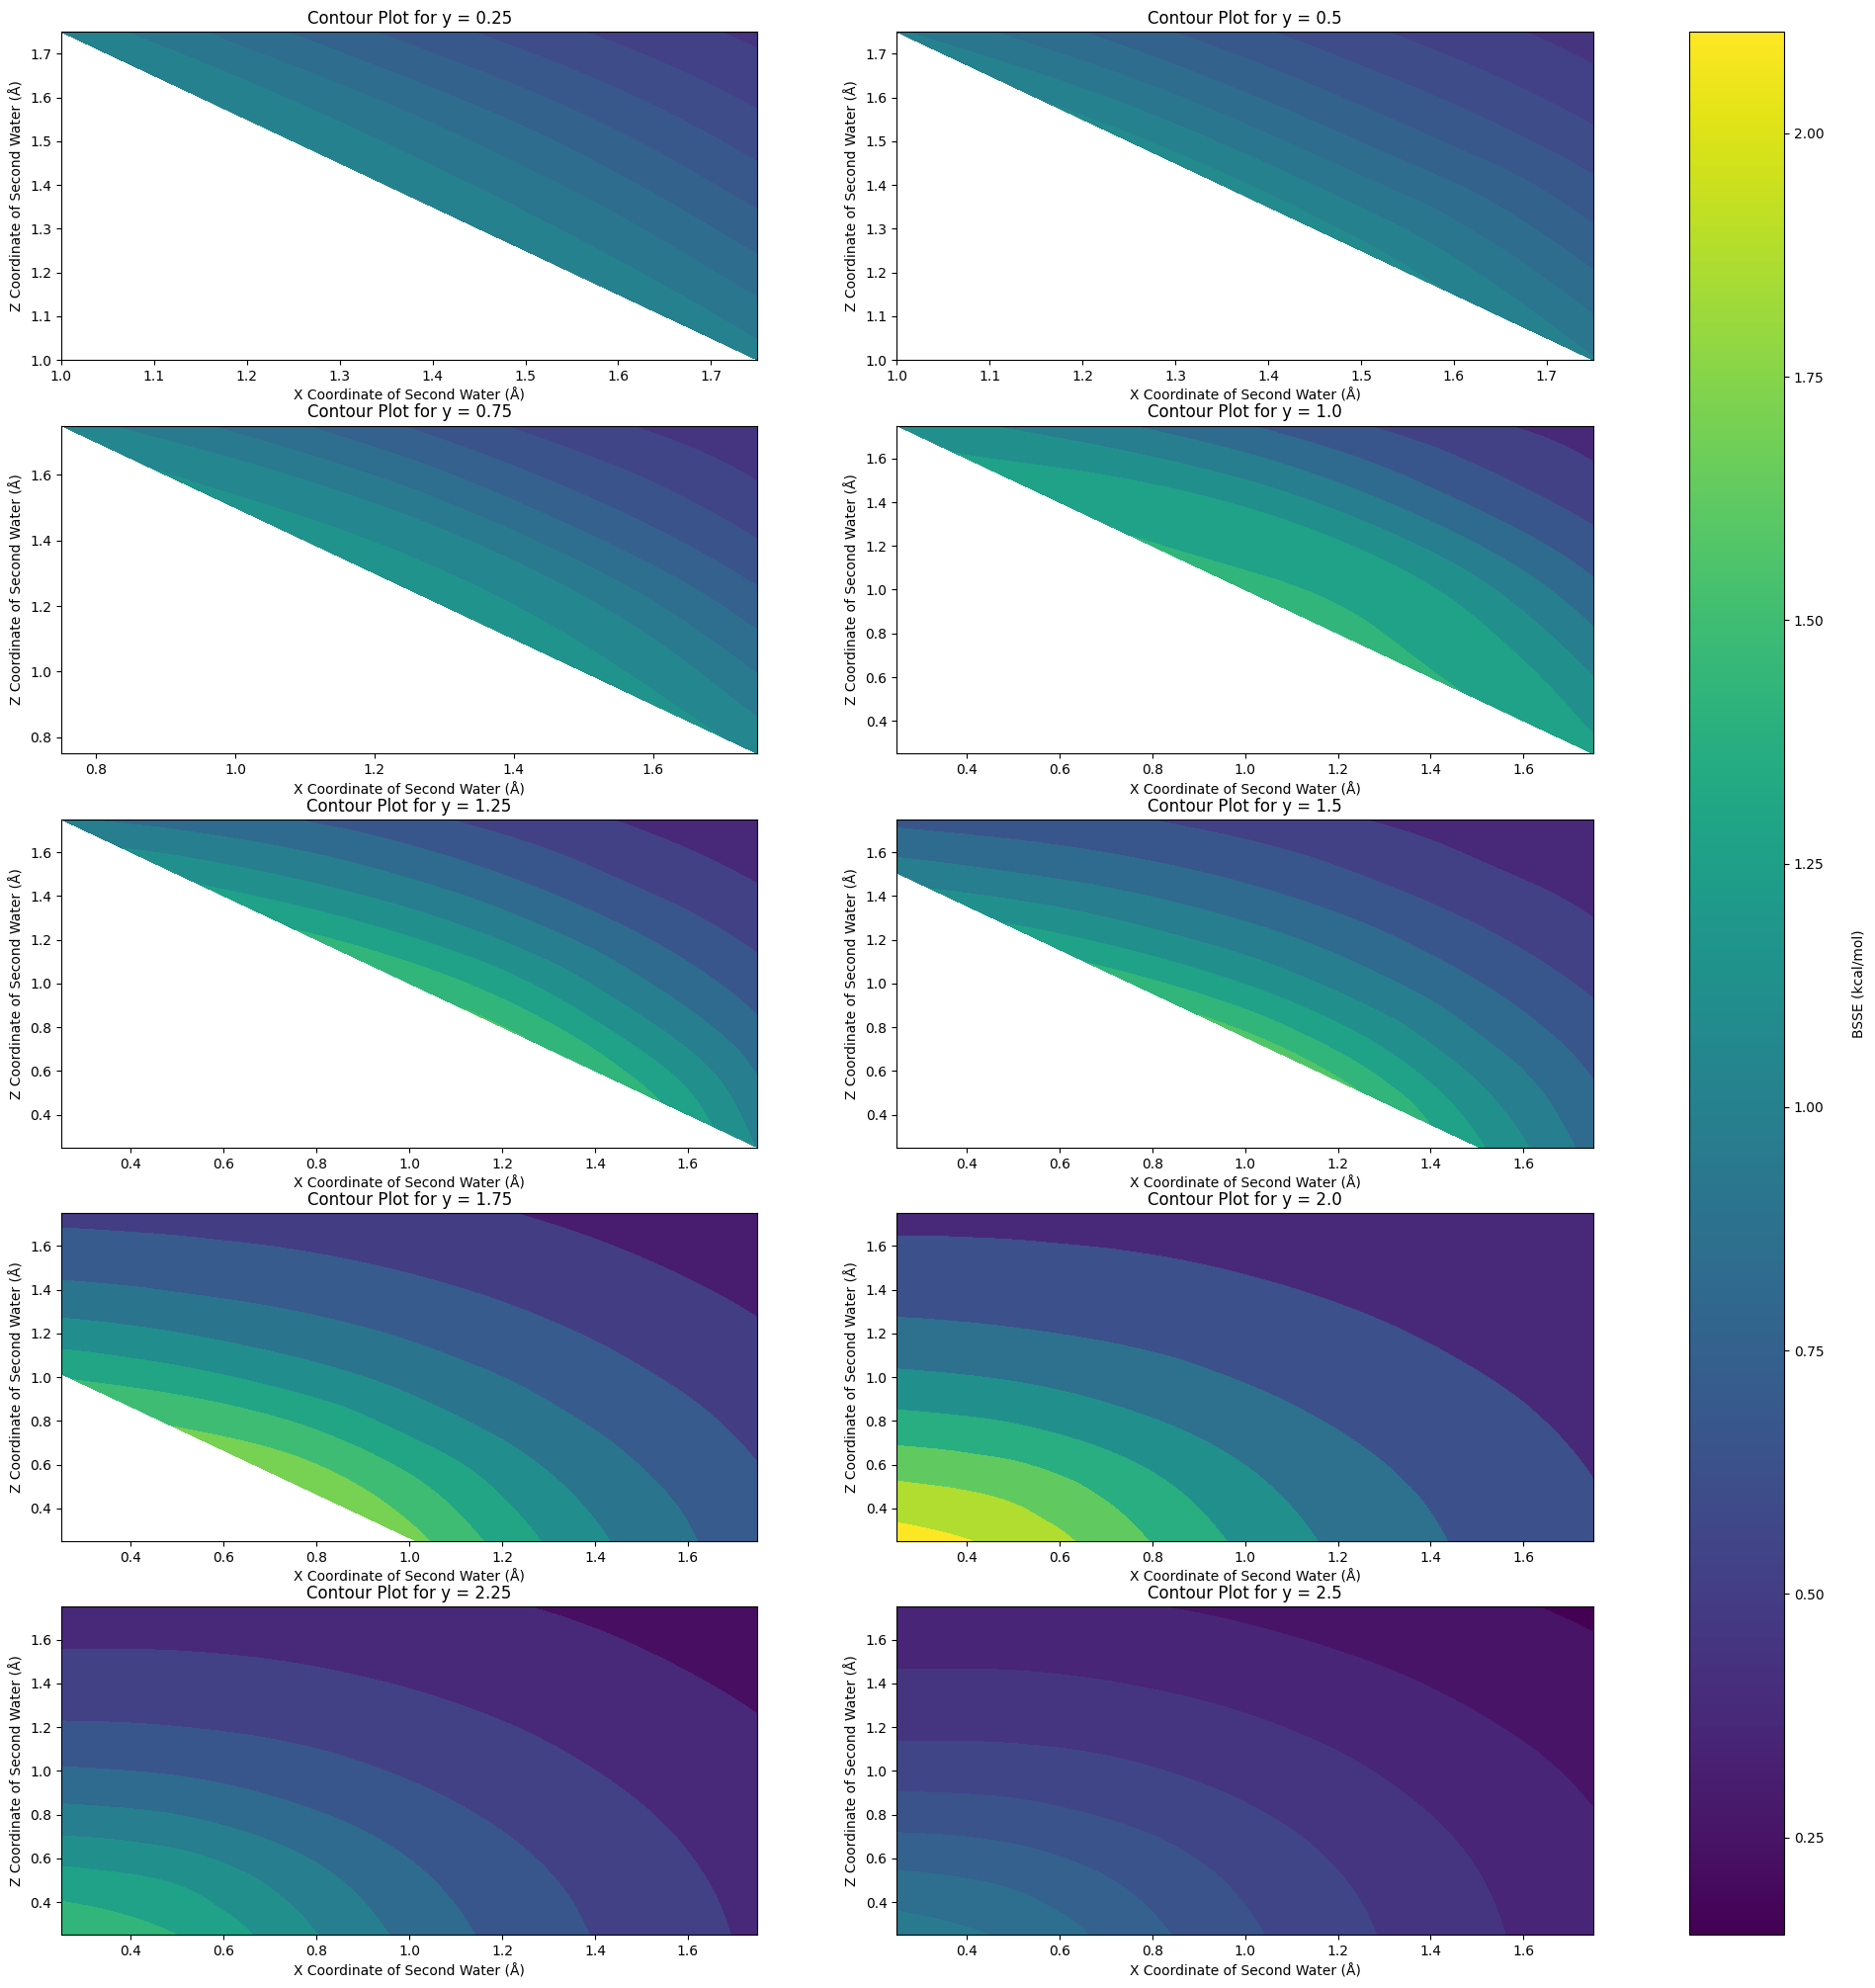

In [25]:
make_bsse_contour_plots(bsse_data_nwchem_kcal, "Water")

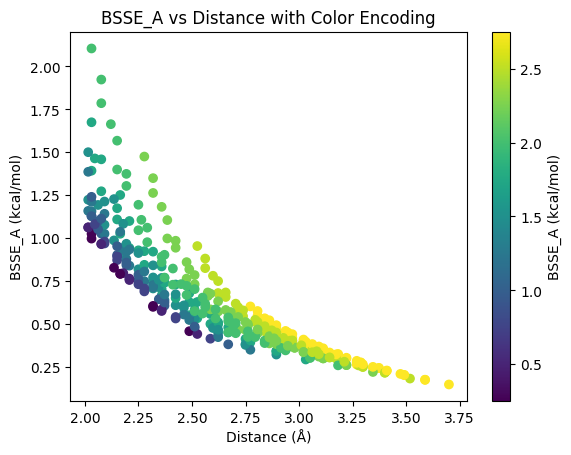

In [26]:
import matplotlib.pyplot as plt

# Compute distance if not already done
bsse_data_nwchem_kcal["distance"] = (
    bsse_data_nwchem_kcal["x"] ** 2
    + bsse_data_nwchem_kcal["y"] ** 2
    + bsse_data_nwchem_kcal["z"] ** 2
) ** 0.5

# Create scatter plot with color based on BSSE_A
sc = plt.scatter(
    bsse_data_nwchem_kcal["distance"],
    bsse_data_nwchem_kcal["BSSE_A"],
    c=bsse_data_nwchem_kcal["y"],
    cmap="viridis",
)

# Add colorbar
plt.colorbar(sc, label="BSSE_A (kcal/mol)")

# Optional: axis labels and title
plt.xlabel("Distance (Å)")
plt.ylabel("BSSE_A (kcal/mol)")
plt.title("BSSE_A vs Distance with Color Encoding")

plt.show()

In [27]:
fit_gauss = fit_gaussian(bsse_data_nwchem_kcal, 2)

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


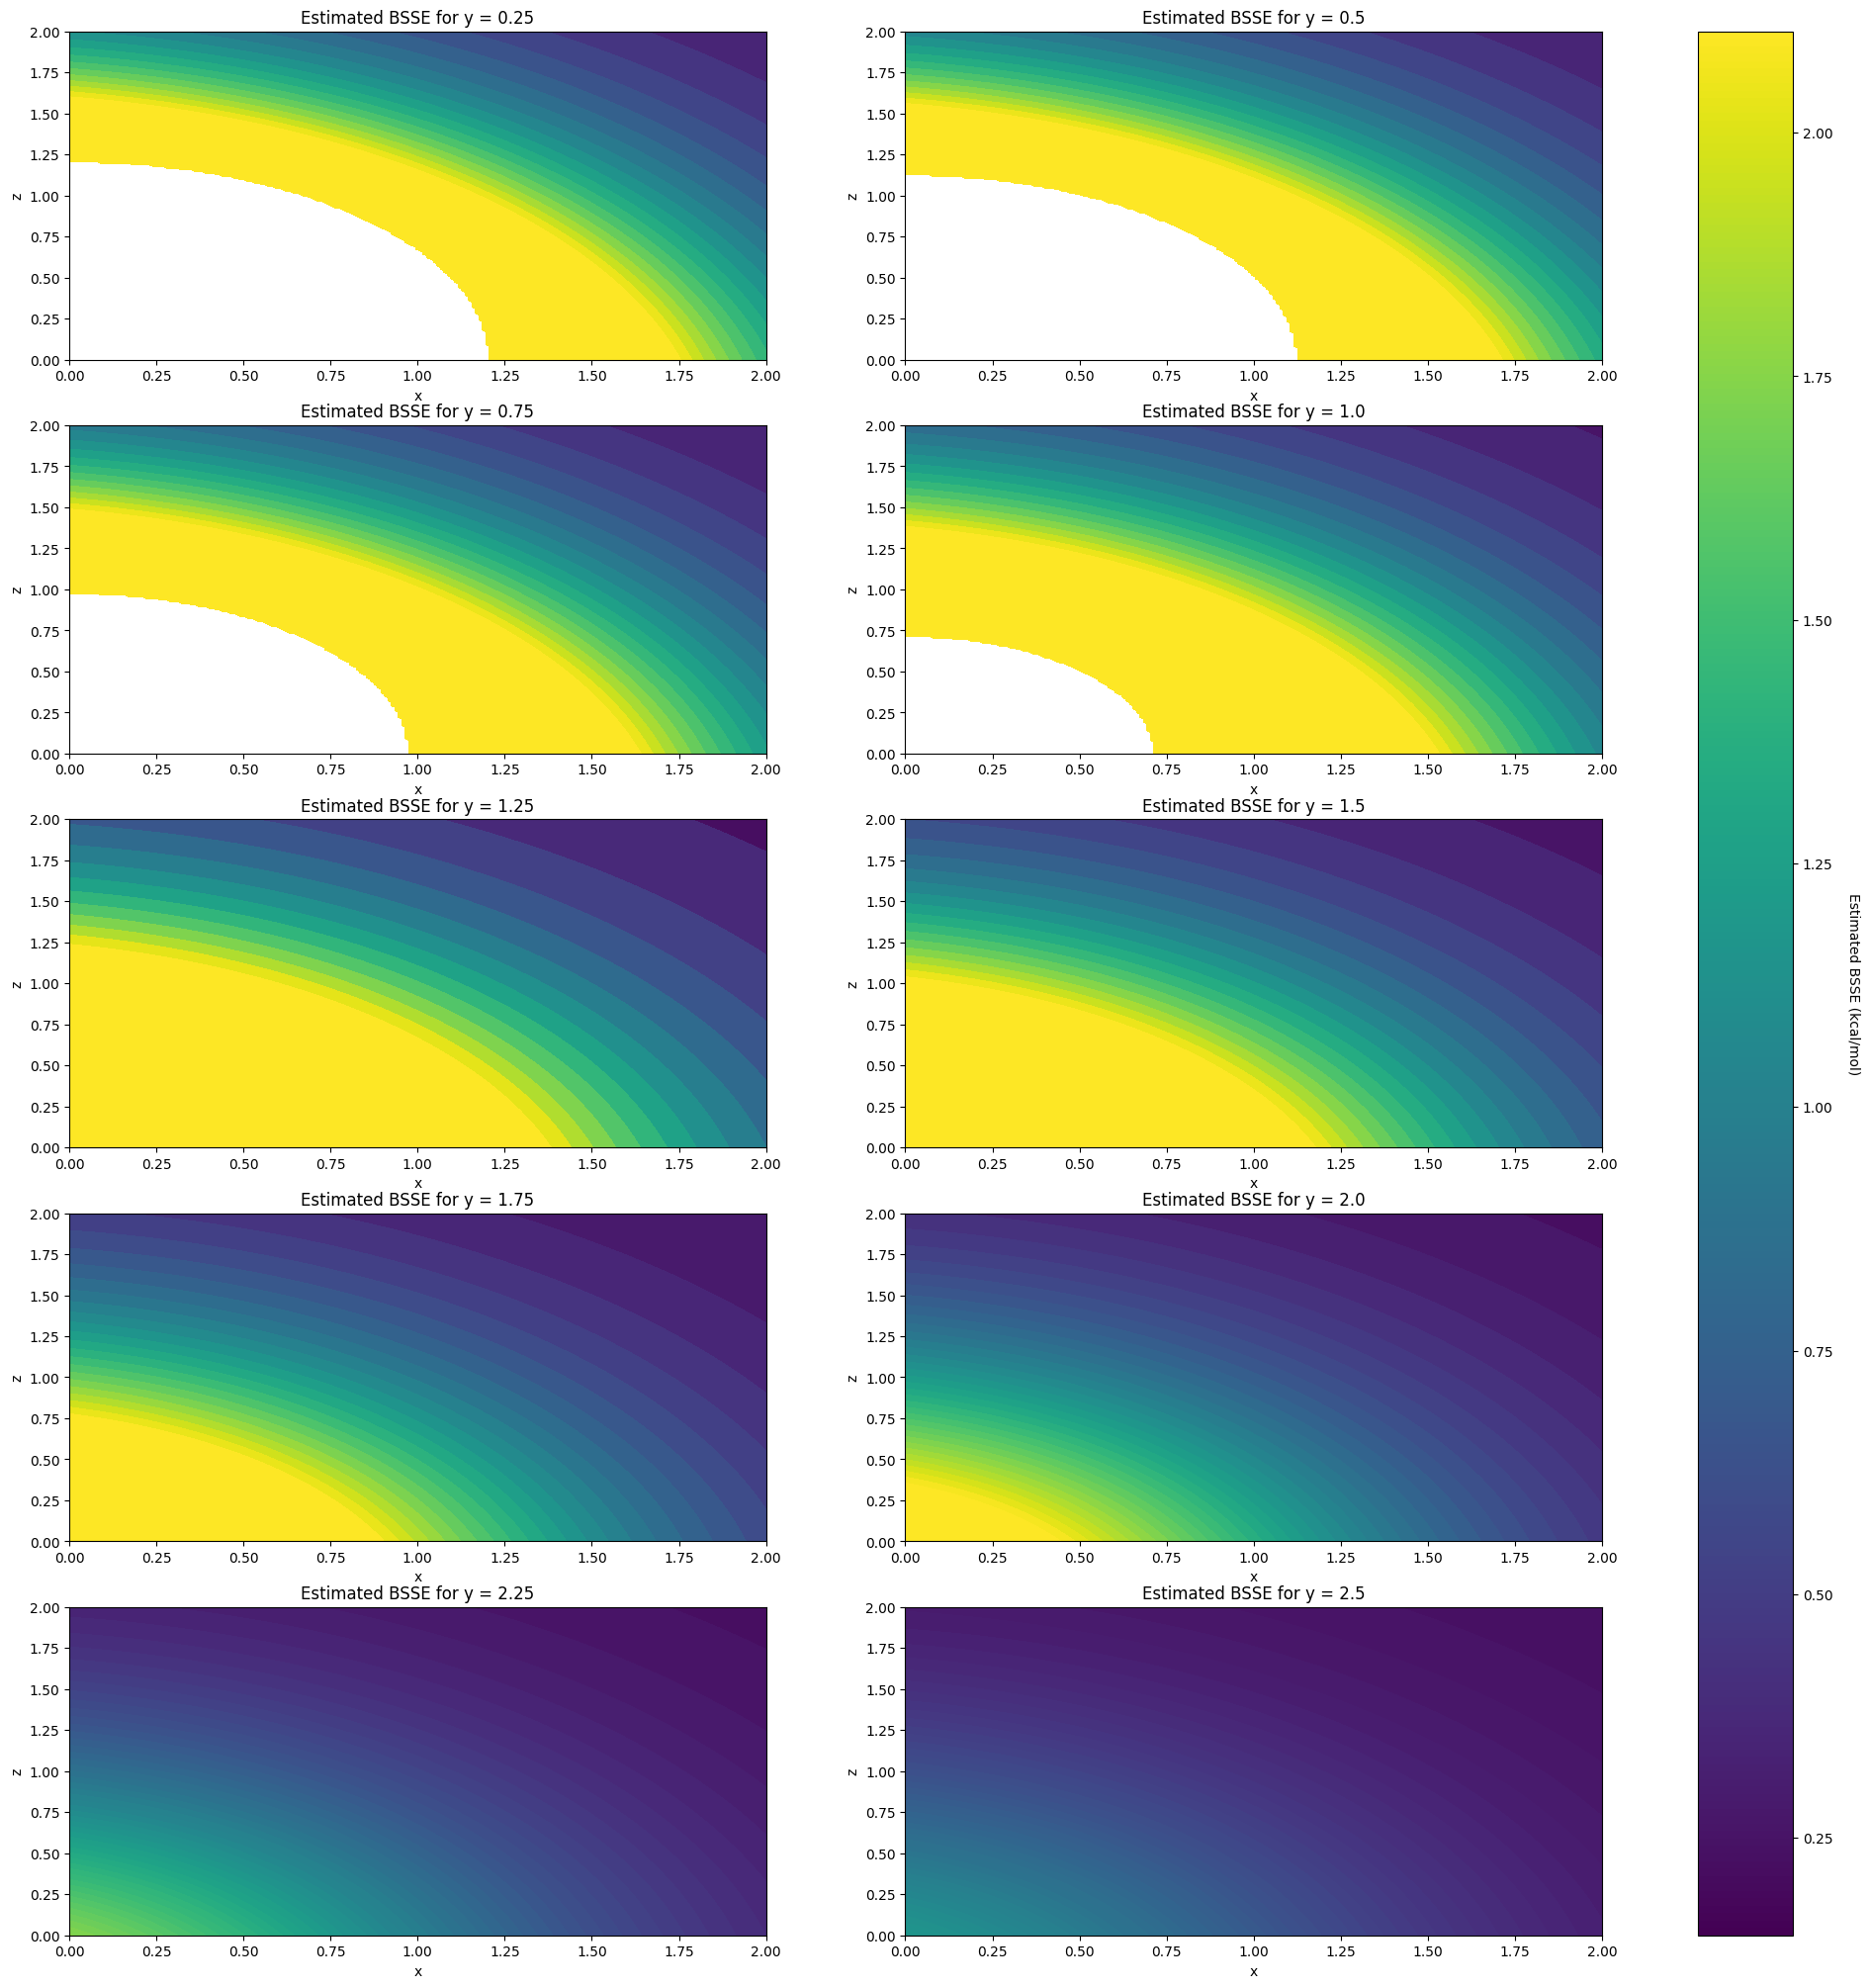

In [28]:
make_contour_plots_of_fitted_gaussian(bsse_data_nwchem_kcal, fit_gauss)

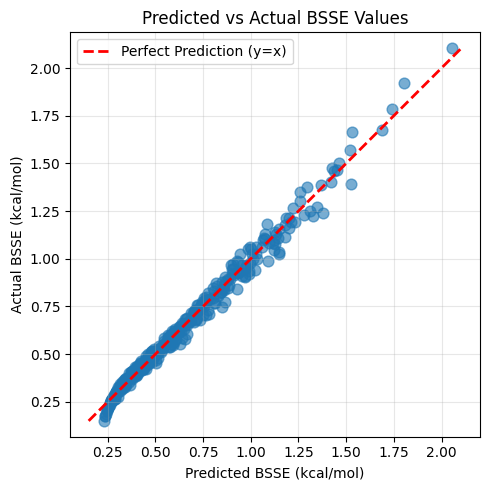

{'RMSE': np.float64(0.036331753459019886),
 'MAE': np.float64(0.026608205907957913),
 '% Error': np.float64(4.56268641657539)}

In [29]:
predicted_v_actual_plot(bsse_data_nwchem_kcal, fit_gauss)

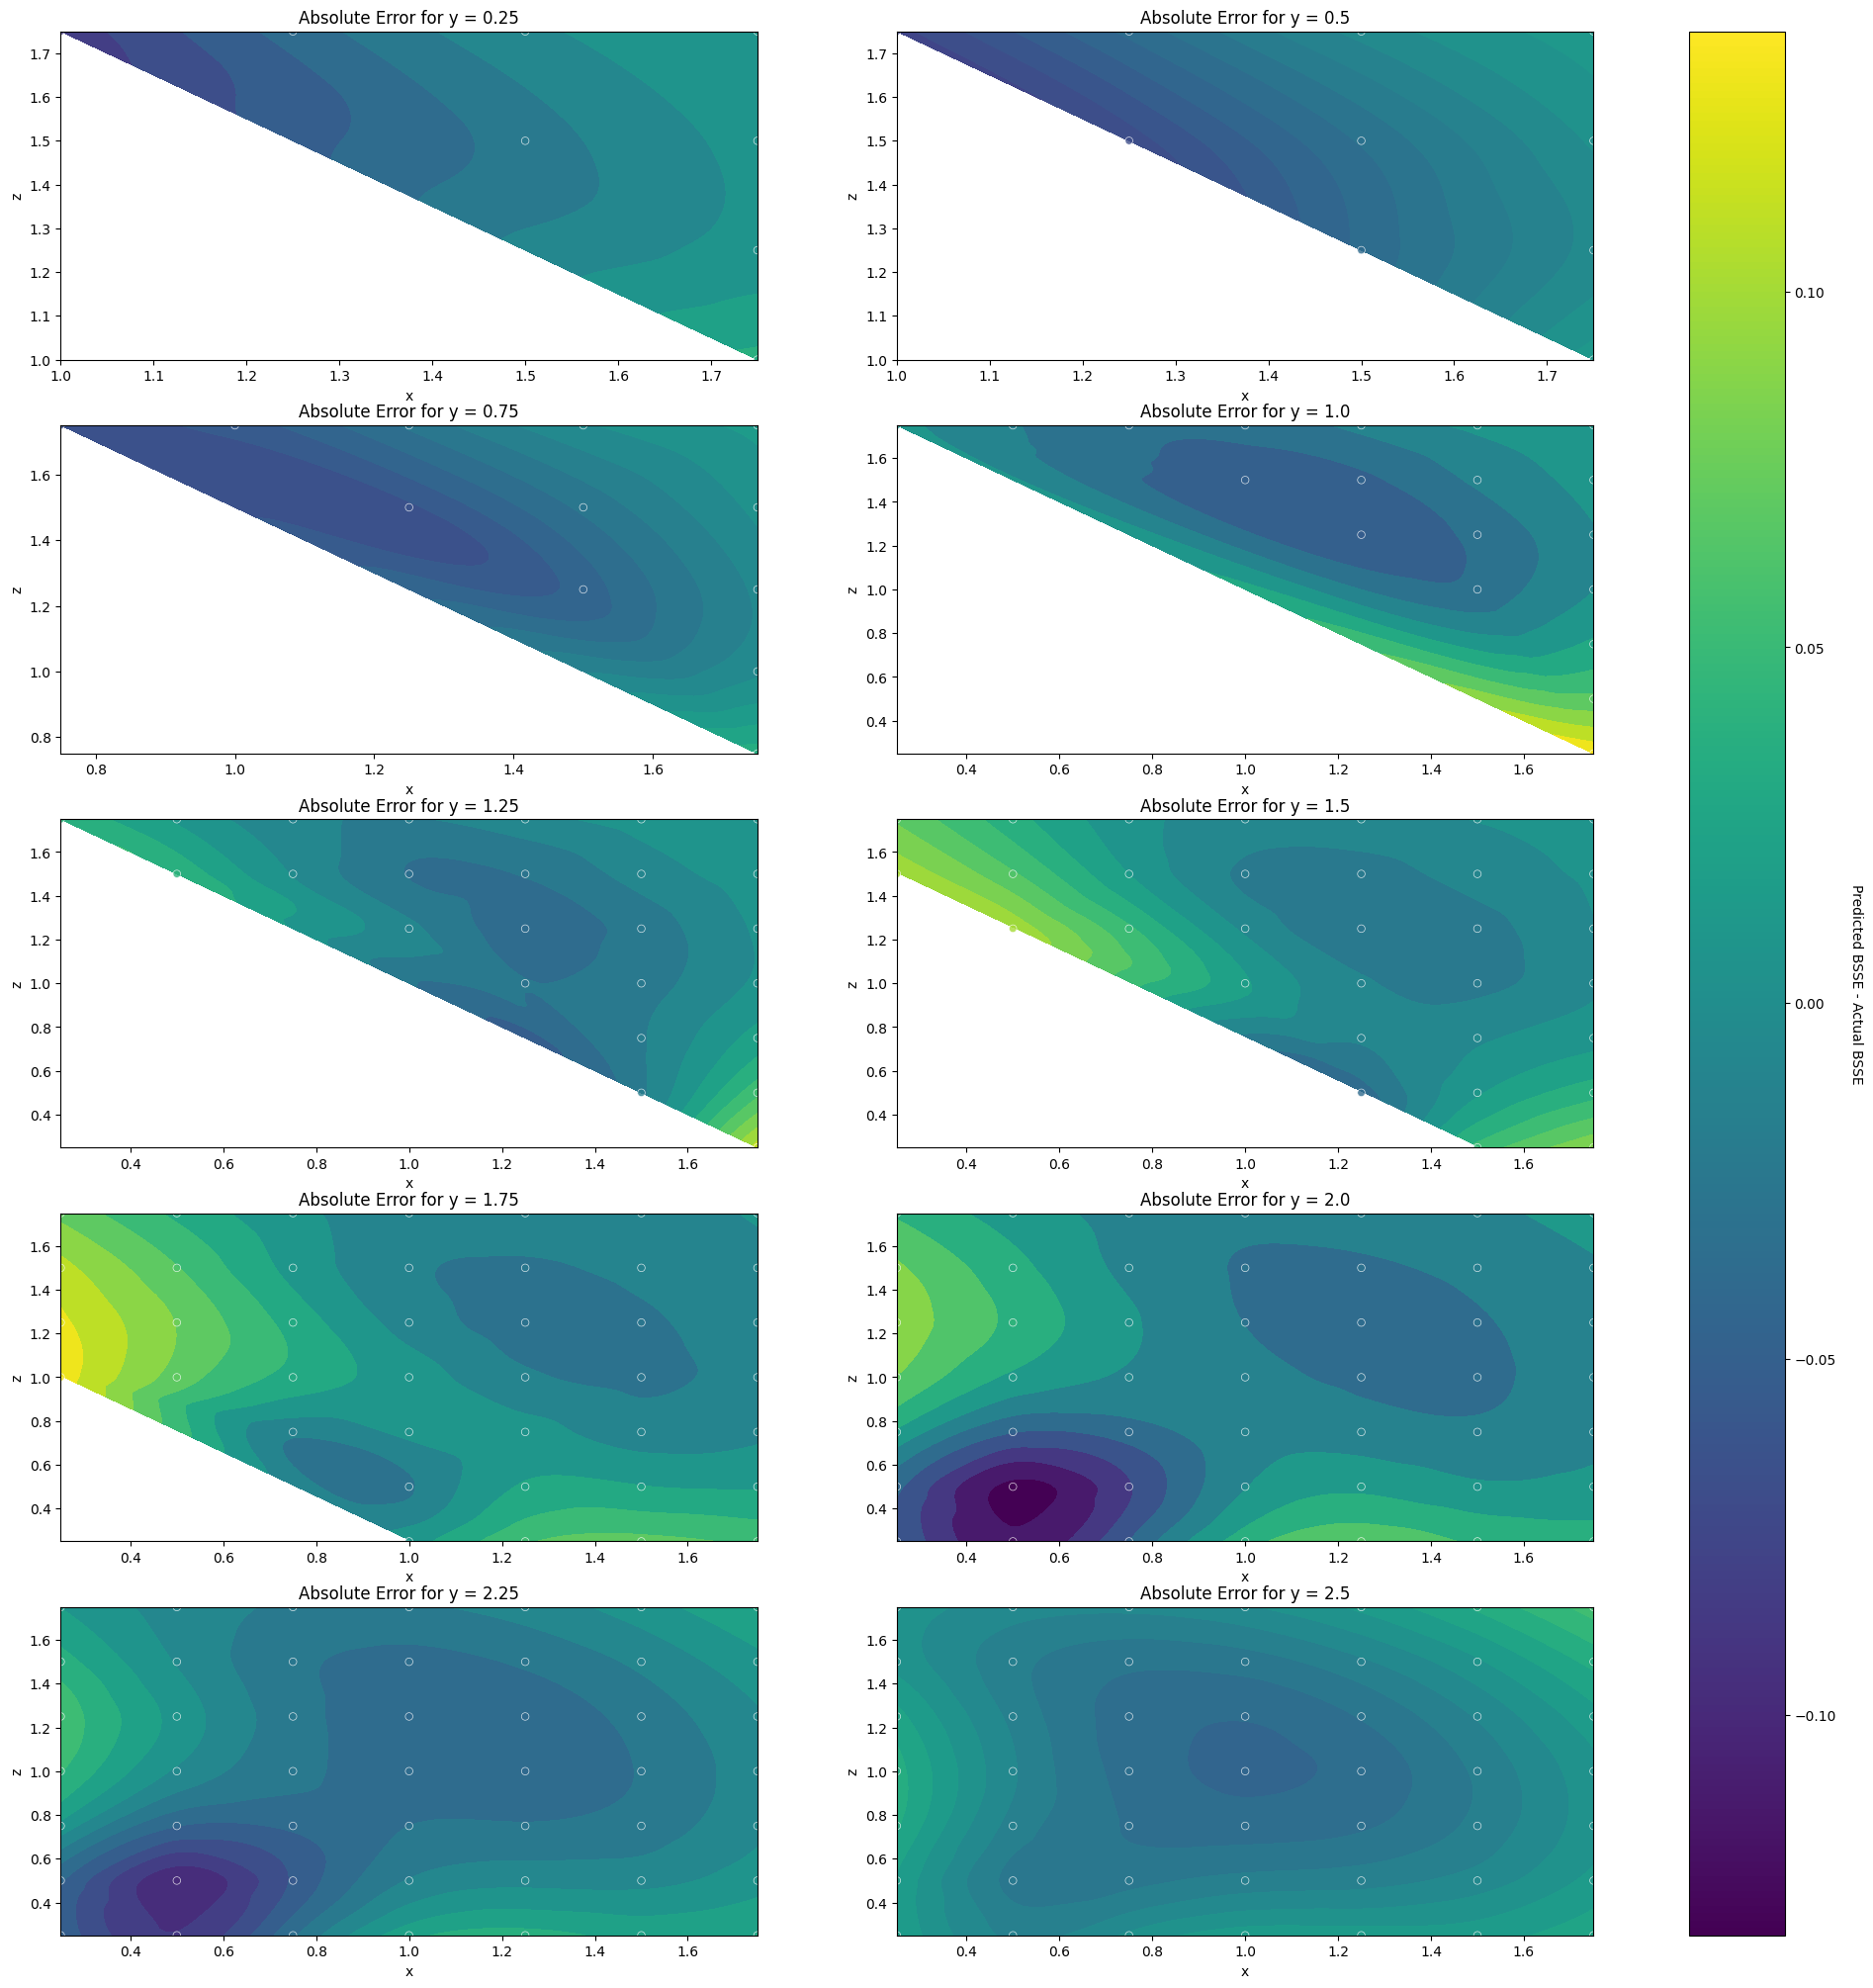

In [30]:
make_error_contour_plots(bsse_data_nwchem_kcal, fit_gauss)

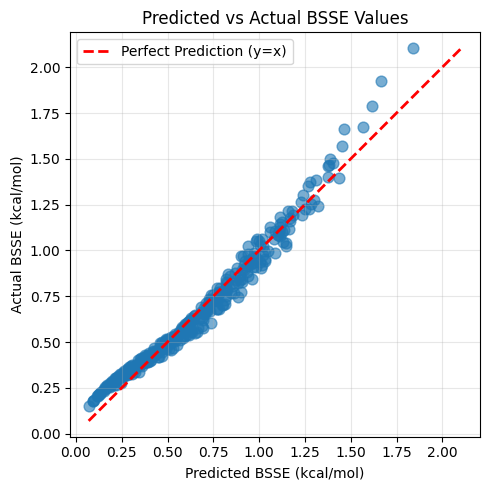

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


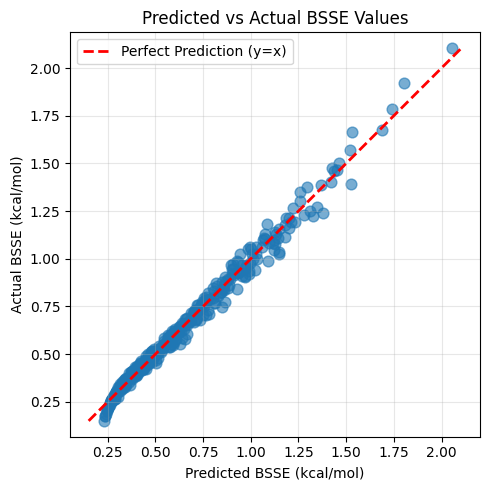

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


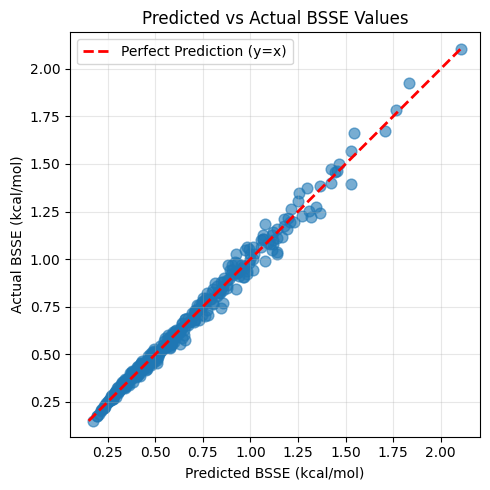

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


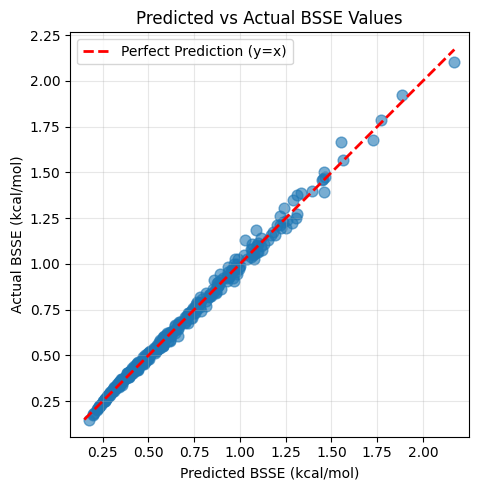

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


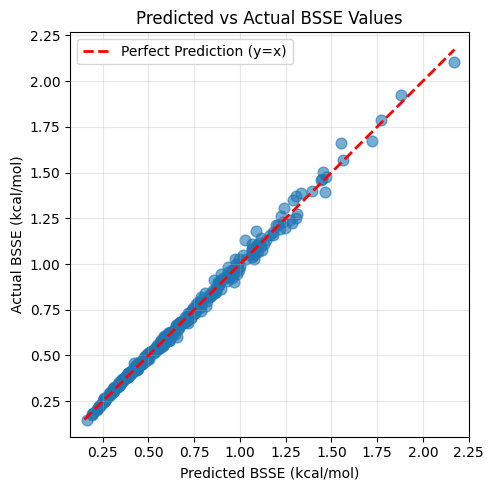

{1: np.float64(9.764837917990958),
 2: np.float64(4.56268641657539),
 3: np.float64(3.7731741305358537),
 4: np.float64(2.420064871153486),
 5: np.float64(2.1907192658988817)}

In [31]:
graph_data = {}
for num_gaussians in range(1, 6):
    fit_gauss = fit_gaussian(bsse_data_nwchem_kcal, num_gaussians)
    percent_error = predicted_v_actual_plot(bsse_data_nwchem_kcal, fit_gauss)["% Error"]
    graph_data[num_gaussians] = percent_error
graph_data

In [32]:
graph_data = pd.DataFrame.from_dict(graph_data, orient="index")

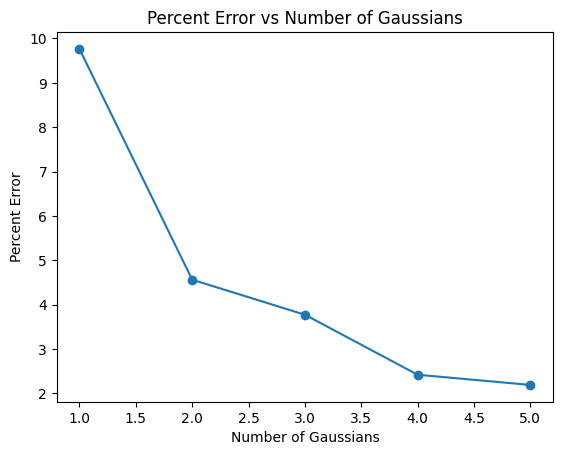

In [36]:
plt.plot(graph_data.index, graph_data[0], marker="o")
plt.xlabel("Number of Gaussians")
plt.ylabel("Percent Error")
plt.title("Percent Error vs Number of Gaussians")
plt.show()